# Demo of DLinear Model for Time Series Forecasting

## 1. Install Dependencies

We need to install `darts` for time series handling and forecasting.

```!pip install --upgrade darts```

## 2. Import Libraries

In [1]:
from darts.datasets import AirPassengersDataset
from darts.models import DLinearModel
from darts.metrics import mape, mae, rmse
import matplotlib.pyplot as plt

## 3. Load and Prepare Data

In [2]:
series = AirPassengersDataset().load()

# Split: use all but last 12 points for training
train, val = series[:-12], series[-12:]
print(f"Training series length: {len(train)}")
print(f"Validation series length: {len(val)}")

Training series length: 132
Validation series length: 12


## 4. Initialize and Train DLinear Model

In [3]:
model = DLinearModel(
    input_chunk_length=36,   # use past 36 months
    output_chunk_length=12,  # predict 12 months at once
)
model.fit(train)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | decomposition   | _SeriesDecomp    | 0      | train
6 | linear_seasonal | L

Training: |                                               | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


DLinearModel(output_chunk_shift=0, shared_weights=False, kernel_size=25, const_init=True, use_static_covariates=True, input_chunk_length=36, output_chunk_length=12)

## 5. Forecast

In [4]:
forecast = model.predict(n=12)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                             | 0/? [00:00<?, ?it/s]

## 6. Evaluation and Visualization

MAPE: 4.34%
MAE:  20.34
RMSE: 24.38


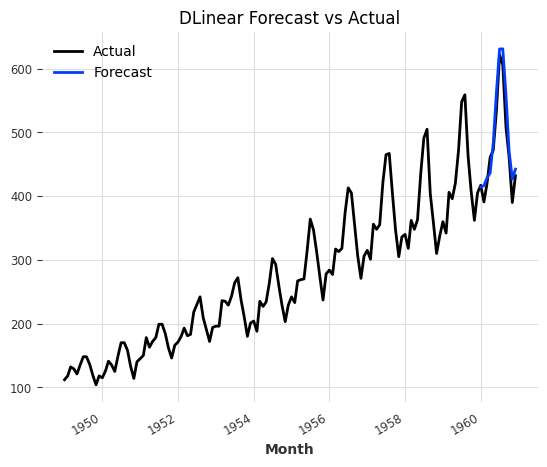

In [5]:
print(f"MAPE: {mape(val, forecast):.2f}%")
print(f"MAE:  {mae(val, forecast):.2f}")
print(f"RMSE: {rmse(val, forecast):.2f}")

# Plot
series.plot(label="Actual")
forecast.plot(label="Forecast")
plt.title("DLinear Forecast vs Actual")
plt.legend();